# 第13周课后练习

- 要求
    - 良好的编程风格
    - 逻辑清楚
    - 简洁

#### 题 1：生成一个维度为n(n<10)的numpy正方形矩阵，具有以下最外层数据均为1，每往中心一层，数据是外层的两倍。


```
3X3的矩阵为：
1 1 1
1 2 1
1 1 1

4X4的矩阵为：
1 1 1 1
1 2 2 1
1 2 2 1
1 1 1 1

5X5的矩阵为：
1 1 1 1 1
1 2 2 2 1
1 2 4 2 1
1 2 2 2 1
1 1 1 1 1
```

import numpy as np

n = int(input('请输入矩阵的维度：'))

# 补充代码
matrix = np.empty((n, n), dtype='int64')
for i in range(n):
    for j in range(n):
        layer = min(i, j, n - 1 - i, n - 1 - j)   # 到最近边界的层数，0 为最外层
        matrix[i, j] = 2 ** layer                 # 每往里一层翻一倍

print(matrix)

#### 题 2：现有一个随机矩阵data，
- 请输出该矩阵每列的平均值和方差
- 将每列减去该列的平均值，并按照实际标准差进行缩放，使得缩放之后的数据标准差为1，形成新的随机矩阵datan，
- 输出datan矩阵的每列平均值和方差

In [ ]:
import numpy as np
data = np.random.normal(0, 1, [10000, 5])

# 补充代码
mean = data.mean(axis=0)
var = data.var(axis=0)
print('原始矩阵每列平均值：', mean)
print('原始矩阵每列方差：', var)

# 每列减去均值，再除以该列标准差，标准化后标准差为 1
datan = (data - mean) / data.std(axis=0)

print('标准化后每列平均值：', datan.mean(axis=0))
print('标准化后每列方差：', datan.var(axis=0))

#### 题 3：有100名学生，对成绩进行统计及排序
- 学号从1~100
- 随机产生数学、英文、语文三门课成绩，均为[40, 100]之间均匀分布的整数，计算出总分，形成一个100X5的矩阵 scores，第一列为学号、第二列~第四列为三门课成绩，第五列为总分
- 按总分从高到低排名
- 统计出每门课不及格的人数，并将其学号列出
- 请使用掩码和花式索引新的数组

In [ ]:
import numpy as np
scores = np.zeros((100,5), dtype='int32')
scores[:, 0] = np.linspace(1, 100, 100)
scores[:, 1:4] = np.random.randint(40, 100, (100, 3))

# 补充代码
# 第五列：三门课总分
scores[:, 4] = scores[:, 1:4].sum(axis=1)

# 按总分从高到低排名（花式索引：用排序后的行下标重排整个矩阵）
ranked = scores[np.argsort(scores[:, 4])[::-1]]
print('按总分从高到低排名：')
print(ranked)

# 统计每门课不及格（< 60）的人数并列出学号
subjects = ['数学', '英文', '语文']
for k, name in enumerate(subjects, start=1):
    mask = scores[:, k] < 60         # 掩码
    fail_ids = scores[mask, 0]       # 花式索引取出对应学号
    print(f'{name}不及格人数：{fail_ids.size}，学号：{fail_ids}')

#### 题 4 若干个平面上的点，逆时针排序
- 平面上有n个点（n>=3）编号为[1, 2, 3, ..., n]，在(0, 1)的范围内随机产生其x和y坐标，形成一个nX2的矩阵points
- 将这n个点按逆时针排序，输出编号
- 使用 matplotlib 模块将点的位置画出来，验证你的结果

逆时针排序后的编号： [1 5 4 2 3 6]


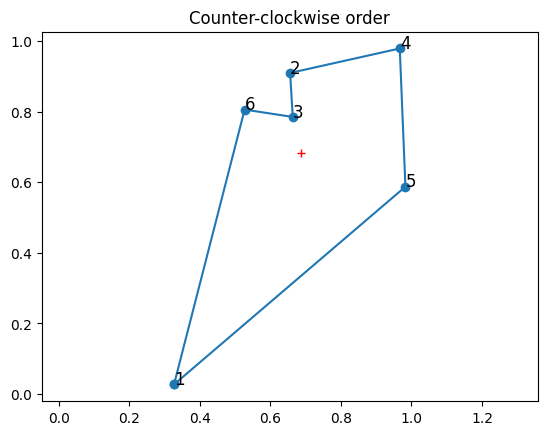

In [2]:
import numpy as np
import matplotlib.pyplot as plt

n = int(input('请输入点的个数（>=3）：'))
points = np.random.random((n, 2))

# 补充代码
center = points.mean(axis=0)                                       # 以质心为参考点
angles = np.arctan2(points[:, 1] - center[1],
                    points[:, 0] - center[0])
order = np.argsort(angles)                                         # 极角递增即为逆时针
labels = order + 1                                                 # 编号从 1 开始

print('逆时针排序后的编号：', labels)

# 画图验证：按逆时针顺序首尾相连
loop = np.append(order, order[0])
plt.figure()
plt.plot(points[loop, 0], points[loop, 1], '-o')
plt.plot(center[0], center[1], 'r+')                               # 标出质心
for idx, (x, y) in enumerate(points, start=1):
    plt.text(x, y, str(idx), fontsize=12)
plt.title('Counter-clockwise order')
plt.axis('equal')
plt.show()

#### 题 5 随机产生一个20X20，值在(0, 1)之间均匀分布的矩阵，找到值与0.5最接近的元素的位置

In [ ]:
import numpy as np

# 补充代码
matrix = np.random.random((20, 20))
idx = np.argmin(np.abs(matrix - 0.5))           # 与 0.5 距离最小的元素的扁平下标
row, col = np.unravel_index(idx, matrix.shape)  # 转换为二维位置

print(f'最接近 0.5 的元素位于第 {row} 行、第 {col} 列，值为 {matrix[row, col]:.6f}')

#### 题 6 编写一个函数，输入参数为一个(n,2)的矩阵，代表n个点的x和y坐标，返回这n个点围成的多边形面积，提示：
- 结合本次作业的第4题
- 将多边形分解为若干个三角形
- 注意凹多边形和凸多边形的区别

In [ ]:
import numpy as np

def polygon_area(points):
    # 结合第 4 题：先按逆时针排序，得到不自交的简单多边形
    center = points.mean(axis=0)
    angles = np.arctan2(points[:, 1] - center[1],
                        points[:, 0] - center[0])
    pts = points[np.argsort(angles)]

    # 鞋带公式：等价于把多边形拆成若干带符号面积的三角形再求和，
    # 凹多边形中“凹陷”部分的三角形面积为负，自动抵消，故凹/凸均适用
    x, y = pts[:, 0], pts[:, 1]
    area = 0.5 * np.abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))
    return area

n = int(input('请输入多边形顶点个数（>=3）：'))
points = np.random.random((n, 2))
print(polygon_area(points))